# CNN - Classificação de Pedestres e Não-Pedestres
Este notebook implementa uma rede neural convolucional (CNN) usando PyTorch para classificar imagens em duas categorias:

- **Pedestre**
- **Não-Pedestre**

Certifique-se de que seu dataset esteja no Google Drive com a seguinte estrutura:
```
MyDrive/dataset_pedestre/
├── Pedestre/
└── Nao-Pedestre/
```


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Caminho para os dados (ajuste se necessário)
data_dir = "/content/drive/MyDrive/Colab Notebooks/Atividades Pos graduaçao/imagens_processamento/Pedestrians-Dataset"

# Transforms
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Dataset e divisão
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
class_names = full_dataset.classes

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_ds, val_ds, test_ds = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

In [ ]:
# Definição da CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
# Inicialização
model = SimpleCNN().to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Treinamento
epochs = 10
train_loss_history = []
val_loss_history = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for epoch in range(epochs):
    model.train()
    running_loss = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss_history.append(running_loss / len(train_loader))

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            val_loss += loss.item()
    val_loss_history.append(val_loss / len(val_loader))

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss_history[-1]:.4f} - Val Loss: {val_loss_history[-1]:.4f}")

Epoch 1/10 - Train Loss: 0.5532 - Val Loss: 0.3917
Epoch 2/10 - Train Loss: 0.2782 - Val Loss: 0.2088
Epoch 3/10 - Train Loss: 0.1274 - Val Loss: 0.1451
Epoch 4/10 - Train Loss: 0.0735 - Val Loss: 0.1197
Epoch 5/10 - Train Loss: 0.0582 - Val Loss: 0.1035
Epoch 6/10 - Train Loss: 0.0245 - Val Loss: 0.1158
Epoch 7/10 - Train Loss: 0.0122 - Val Loss: 0.1027
Epoch 8/10 - Train Loss: 0.0141 - Val Loss: 0.1406
Epoch 9/10 - Train Loss: 0.0059 - Val Loss: 0.1085
Epoch 10/10 - Train Loss: 0.0023 - Val Loss: 0.1172


In [ ]:
# Avaliação no conjunto de teste
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(lbls.numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

  Background       0.98      0.98      0.98       445
 Pedestrians       0.96      0.96      0.96       191

    accuracy                           0.98       636
   macro avg       0.97      0.97      0.97       636
weighted avg       0.98      0.98      0.98       636



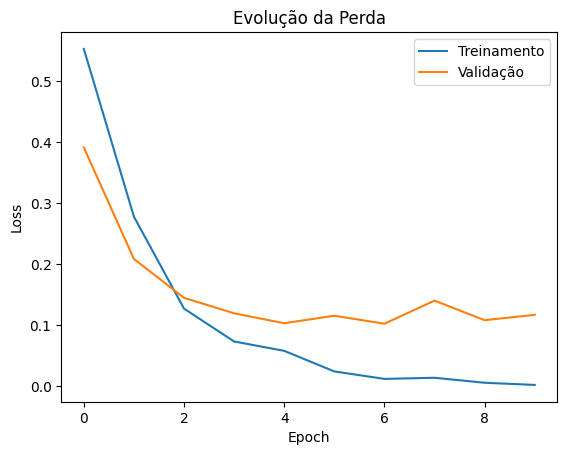

In [ ]:
# Gráfico de perda
plt.plot(train_loss_history, label="Treinamento")
plt.plot(val_loss_history, label="Validação")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Evolução da Perda")
plt.show()

In [ ]:
# Salvar pesos
torch.save(model.state_dict(), "modelo_cnn_pedestre.pth")
print("Modelo salvo!")

Modelo salvo!
